# Importing all required libraries

In [1]:
#Import Libraries

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

from mlxtend.plotting import plot_decision_regions

## Loading Dataset

In [2]:
#Load Dataset

df = pd.read_csv(r"/content/Chronic_Kidney_Disease_data.csv")

In [3]:
#Display First 3 Rows

df.head(3)

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,...,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,...,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,...,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential


In [4]:
#Check Dataset Shape

df.shape

(1659, 54)

In [5]:
#Dataset Information Summary

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PatientID                      1659 non-null   int64  
 1   Age                            1659 non-null   int64  
 2   Gender                         1659 non-null   int64  
 3   Ethnicity                      1659 non-null   int64  
 4   SocioeconomicStatus            1659 non-null   int64  
 5   EducationLevel                 1659 non-null   int64  
 6   BMI                            1659 non-null   float64
 7   Smoking                        1659 non-null   int64  
 8   AlcoholConsumption             1659 non-null   float64
 9   PhysicalActivity               1659 non-null   float64
 10  DietQuality                    1659 non-null   float64
 11  SleepQuality                   1659 non-null   float64
 12  FamilyHistoryKidneyDisease     1659 non-null   i

In [6]:
#Statistical Summary of Dataset

df.describe()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis
count,1659.000000,1659.000000,1659.000000,1659.00000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,...,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000,1659.000000
mean,830.000000,54.441230,0.515371,0.71308,0.977697,1.693189,27.620049,0.292948,9.969831,5.024247,...,3.525510,5.054869,49.730659,0.044002,0.103074,0.197107,2.000336,4.947788,5.144973,0.918626
std,479.056364,20.549757,0.499914,1.00043,0.776686,0.910611,7.288670,0.455252,5.798787,2.866274,...,2.026131,2.880460,27.827593,0.205162,0.304147,0.397934,1.141635,2.869959,2.901138,0.273492
min,1.000000,20.000000,0.000000,0.00000,0.000000,0.000000,15.033888,0.000000,0.021740,0.001186,...,0.006327,0.013697,0.087256,0.000000,0.000000,0.000000,0.001082,0.005392,0.004436,0.000000
25%,415.500000,36.000000,0.000000,0.00000,0.000000,1.000000,21.471449,0.000000,5.051156,2.555038,...,1.820793,2.532867,26.991708,0.000000,0.000000,0.000000,1.005802,2.498119,2.569561,1.000000
50%,830.000000,54.000000,1.000000,0.00000,1.000000,2.000000,27.652077,0.000000,9.951503,5.072395,...,3.572522,5.087086,48.970075,0.000000,0.000000,0.000000,2.040635,4.974069,5.182949,1.000000
75%,1244.500000,72.000000,1.000000,1.00000,2.000000,2.000000,34.015849,1.000000,14.967100,7.460563,...,5.254956,7.552093,73.913997,0.000000,0.000000,0.000000,2.947213,7.499783,7.733253,1.000000
max,1659.000000,90.000000,1.000000,3.00000,2.000000,3.000000,39.993532,1.000000,19.992713,9.998167,...,6.984636,9.998313,99.987510,1.000000,1.000000,1.000000,3.999469,9.992345,9.993754,1.000000


Assess the data for linear versus non-linear patterns.

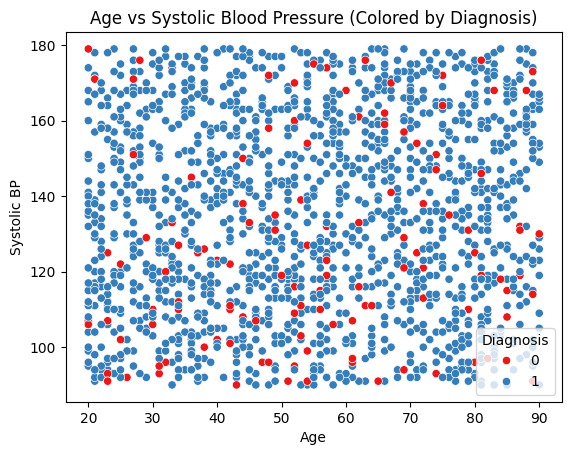

In [7]:
sns.scatterplot(
    x='Age',
    y='SystolicBP',
    hue='Diagnosis',
    data=df,
    palette='Set1'
)

plt.title("Age vs Systolic Blood Pressure (Colored by Diagnosis)")
plt.xlabel("Age")
plt.ylabel("Systolic BP")
plt.show()


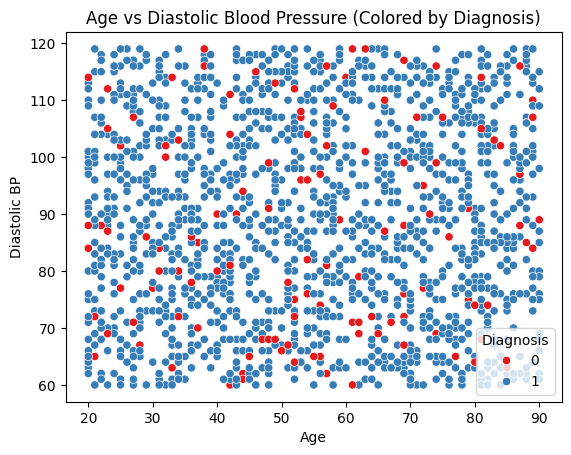

In [8]:
#Scatterplot (Age vs Diastolic BP)

sns.scatterplot(x='Age', y='DiastolicBP', hue='Diagnosis', data=df, palette='Set1')
plt.title("Age vs Diastolic Blood Pressure (Colored by Diagnosis)")
plt.xlabel("Age")
plt.ylabel("Diastolic BP")
plt.show()

# Null Value Identification

In [9]:
#Check for Missing Values

df.isnull()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1654,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1655,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1656,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1657,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
#Percentage of Missing Values in the Entire Dataset

df.isnull().sum().sum()/(df.shape[0]*df.shape[1])*100

np.float64(0.0)

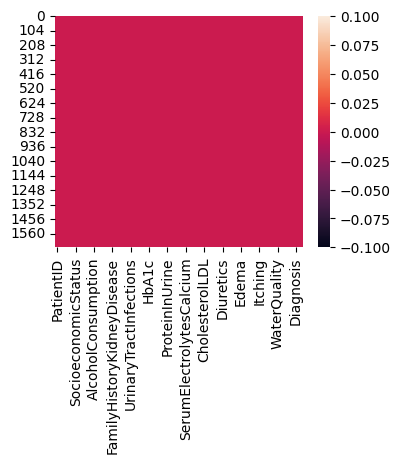

In [11]:
#Heatmap of Missing Values

plt.figure(figsize=(4,3))
sns.heatmap(df.isnull())
plt.show()

In [12]:
#Drop a Column from the Dataset

df = df.drop('DoctorInCharge', axis=1)

In [13]:
#Select Numerical Columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# OUTLIER DETECTION AND HANDLING

In [15]:
# OUTLIER DETECTION AND HANDLING (IQR METHOD)

# Select only numeric columns (EXCLUDING Diagnosis)
numeric_cols = df.select_dtypes(include=np.number).columns.drop("Diagnosis", errors="ignore")

# Calculate Q1, Q3 and IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Bounds for IQR method
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(" OUTLIER DETECTION ")

# Count outliers for each column
outlier_counts = {}
for col in numeric_cols:
    outliers = ((df[col] < lower_bound[col]) | (df[col] > upper_bound[col])).sum()
    outlier_counts[col] = outliers
    print(f"{col}: {outliers} outliers")

total_outliers = sum(outlier_counts.values())
print("\nTotal Outliers in Dataset:", total_outliers)

print("\n HANDLING OUTLIERS (CAPPING) ")

# Handle outliers using capping
df[numeric_cols] = df[numeric_cols].clip(lower_bound, upper_bound, axis=1)

print(" Outliers handled using capping (no rows removed).")
print(f"Total Rows After Handling: {df.shape[0]}")


 OUTLIER DETECTION 
PatientID: 0 outliers
Age: 0 outliers
Gender: 0 outliers
Ethnicity: 0 outliers
SocioeconomicStatus: 0 outliers
EducationLevel: 0 outliers
BMI: 0 outliers
Smoking: 0 outliers
AlcoholConsumption: 0 outliers
PhysicalActivity: 0 outliers
DietQuality: 0 outliers
SleepQuality: 0 outliers
FamilyHistoryKidneyDisease: 0 outliers
FamilyHistoryHypertension: 0 outliers
FamilyHistoryDiabetes: 0 outliers
PreviousAcuteKidneyInjury: 0 outliers
UrinaryTractInfections: 0 outliers
SystolicBP: 0 outliers
DiastolicBP: 0 outliers
FastingBloodSugar: 0 outliers
HbA1c: 0 outliers
SerumCreatinine: 0 outliers
BUNLevels: 0 outliers
GFR: 0 outliers
ProteinInUrine: 0 outliers
ACR: 0 outliers
SerumElectrolytesSodium: 0 outliers
SerumElectrolytesPotassium: 0 outliers
SerumElectrolytesCalcium: 0 outliers
SerumElectrolytesPhosphorus: 0 outliers
HemoglobinLevels: 0 outliers
CholesterolTotal: 0 outliers
CholesterolLDL: 0 outliers
CholesterolHDL: 0 outliers
CholesterolTriglycerides: 0 outliers
ACEInhib

# Boxplots BEFORE Outlier Handling

Before Outlier Detection (Boxplots)


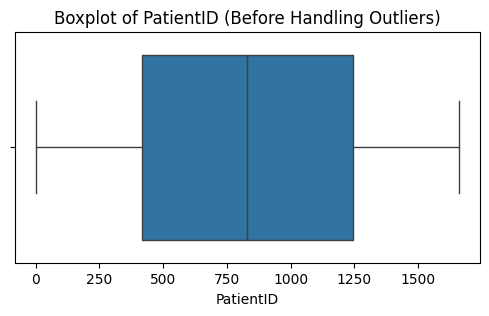

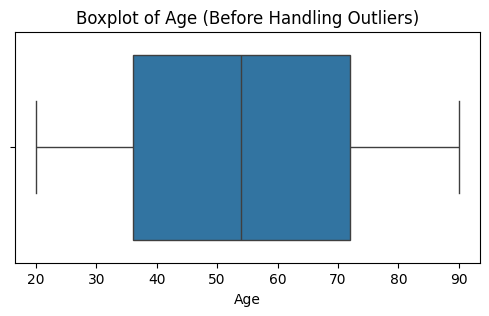

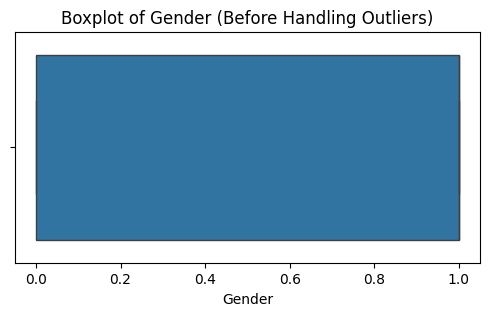

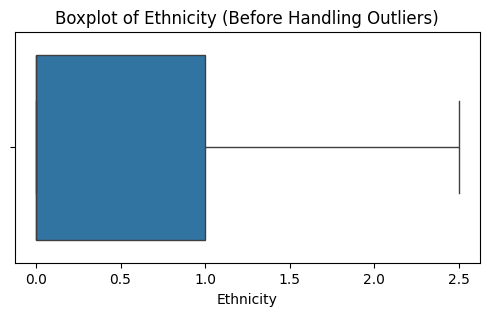

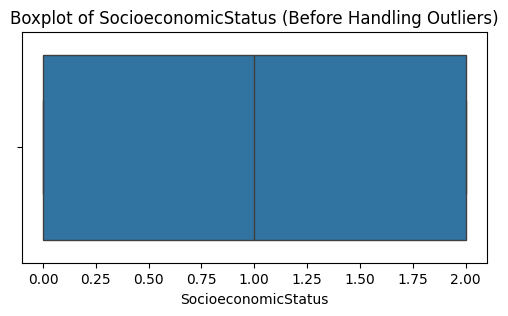

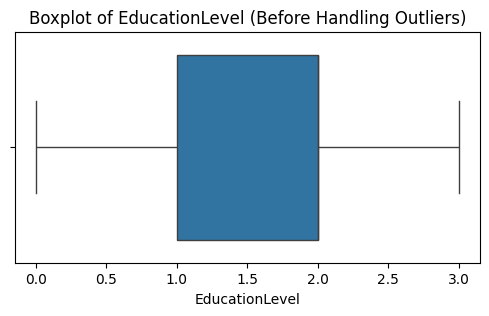

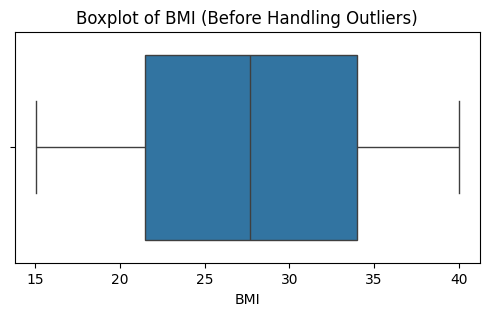

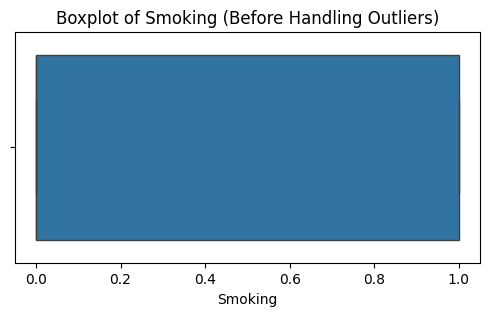

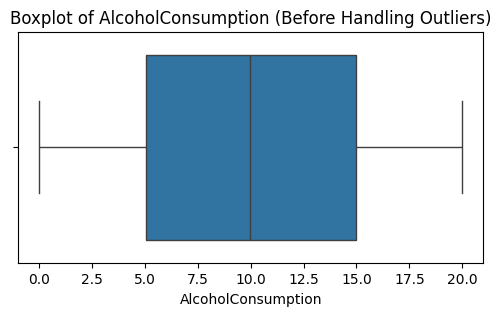

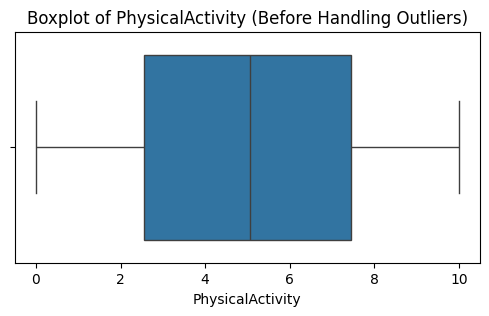

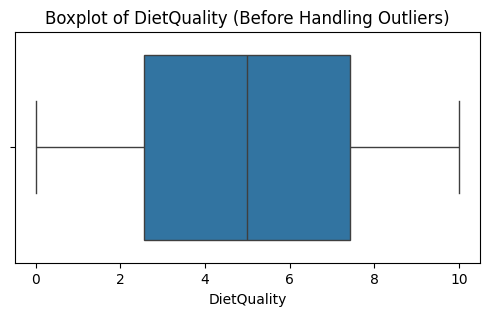

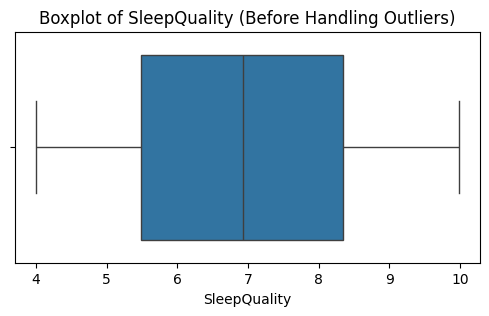

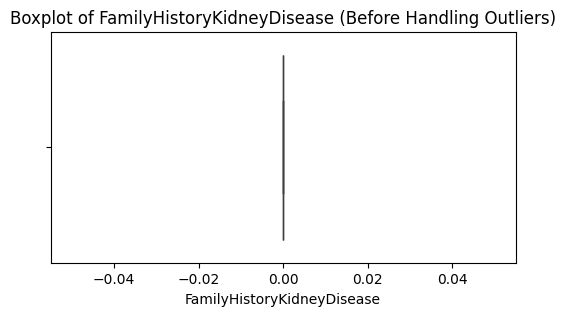

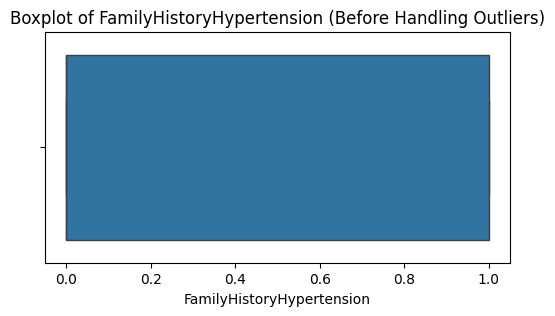

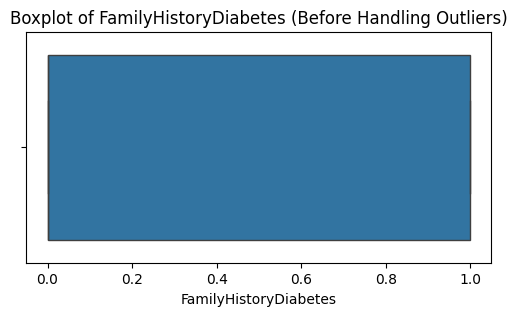

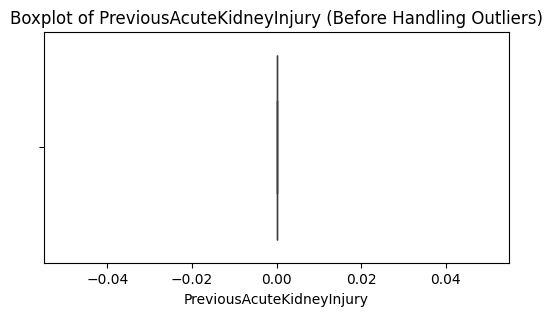

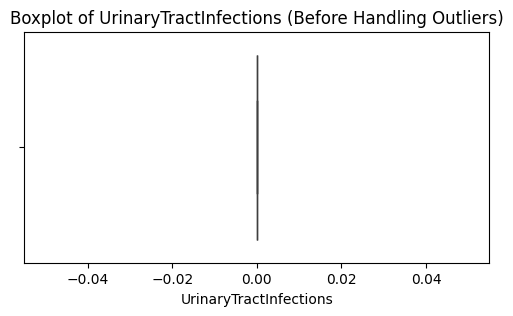

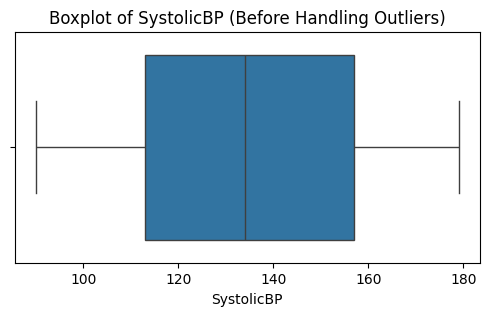

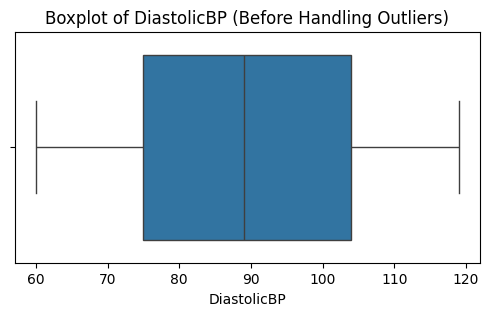

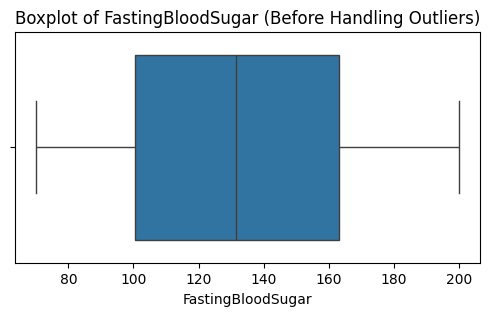

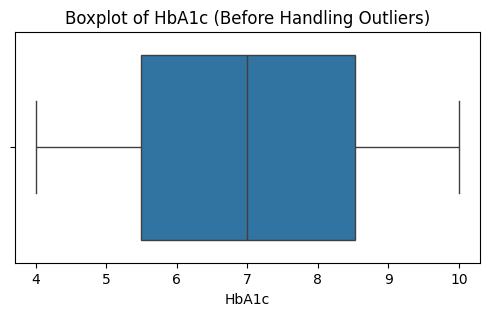

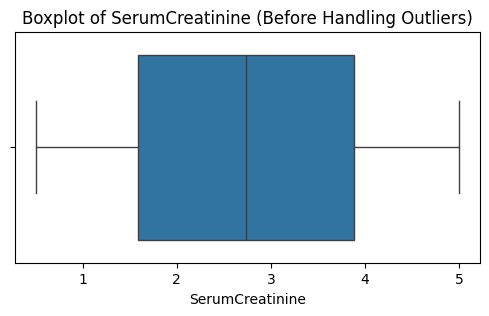

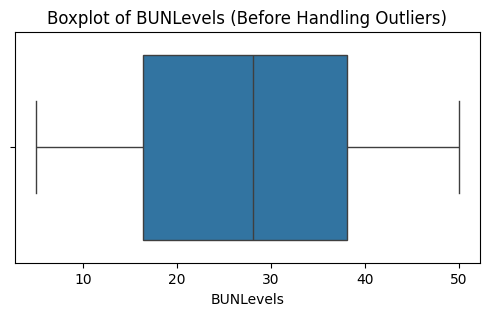

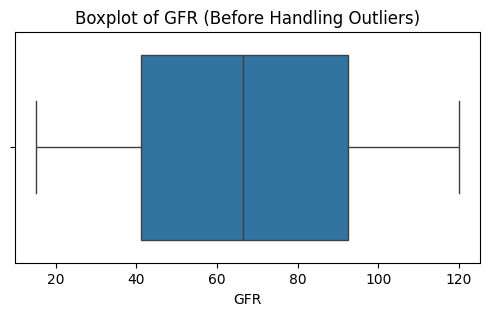

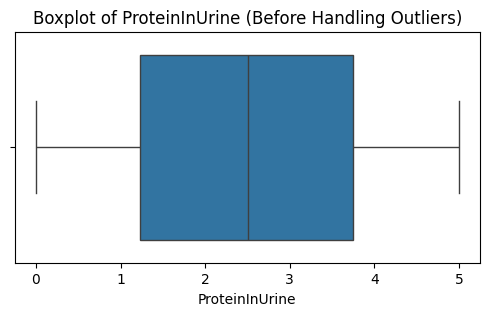

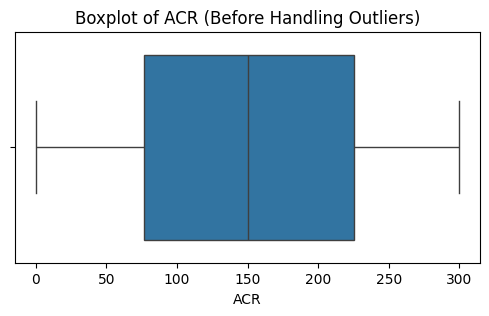

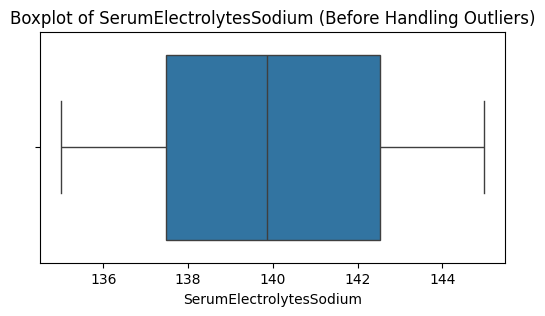

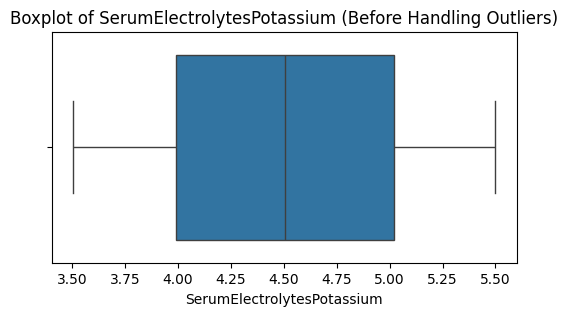

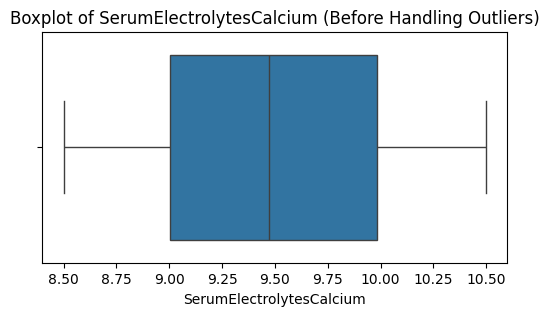

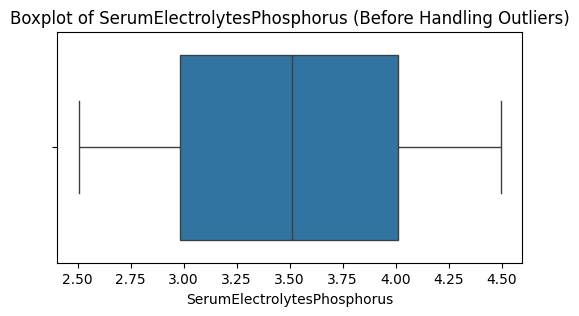

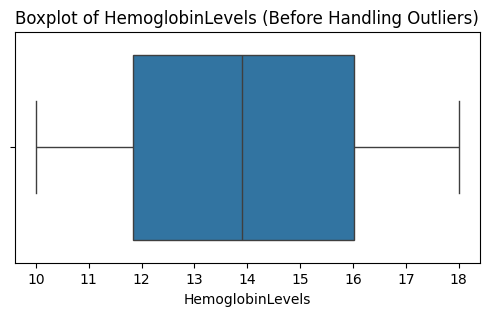

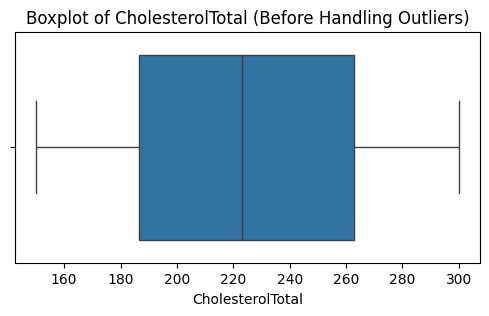

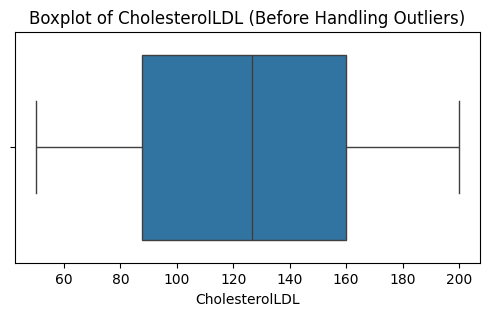

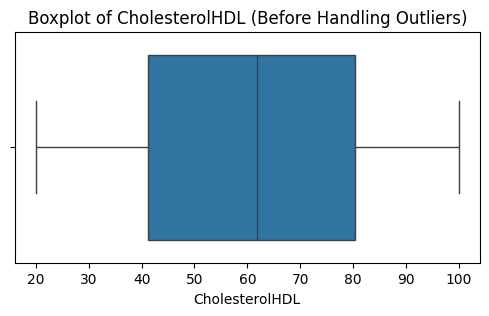

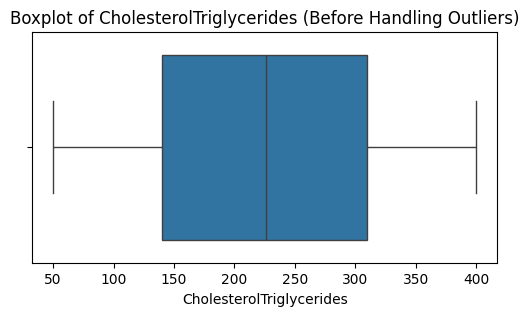

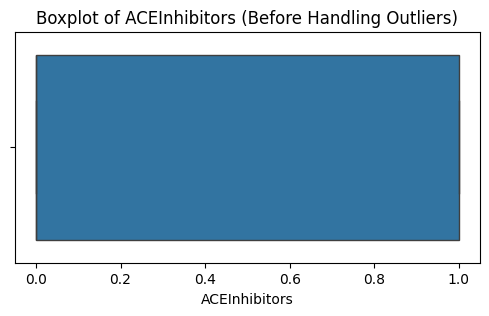

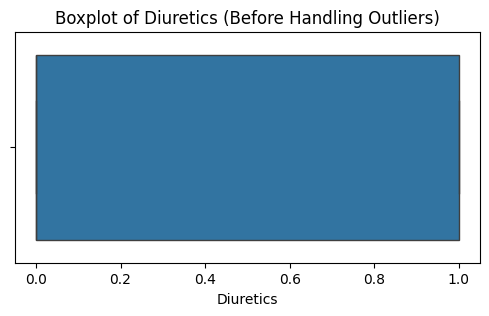

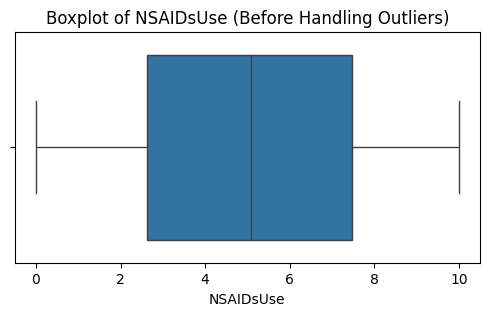

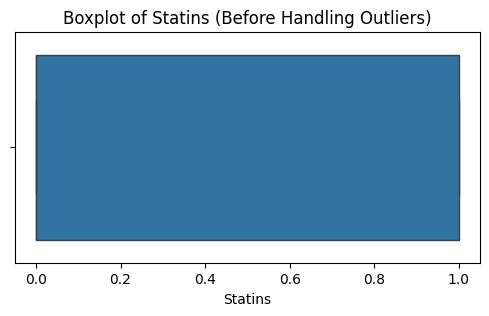

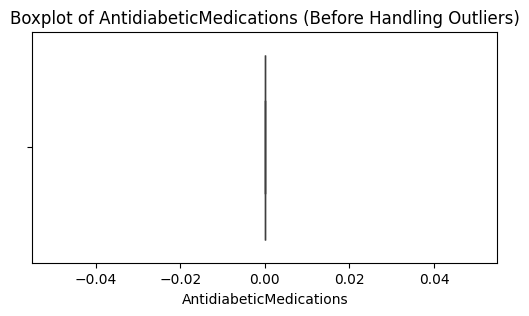

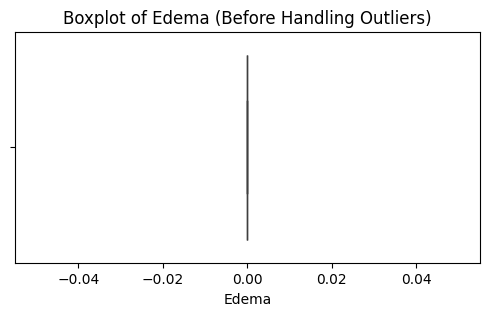

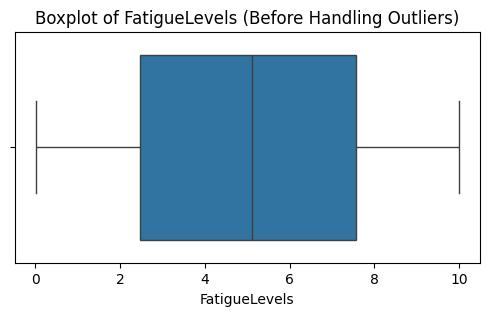

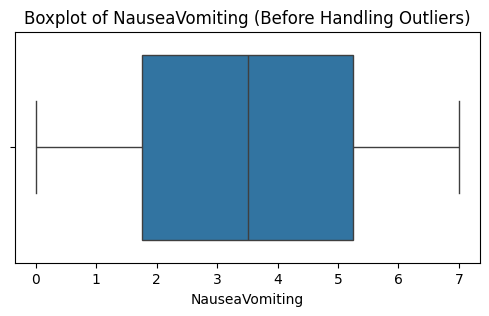

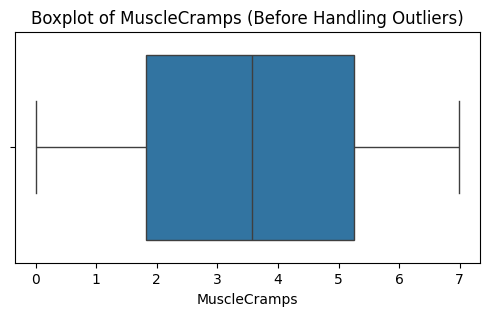

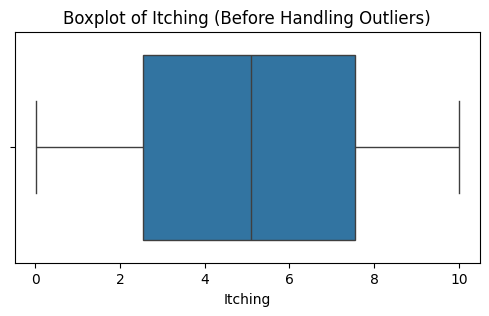

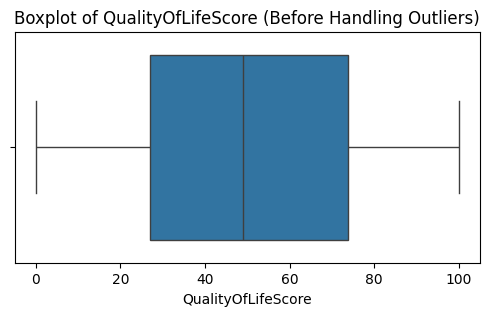

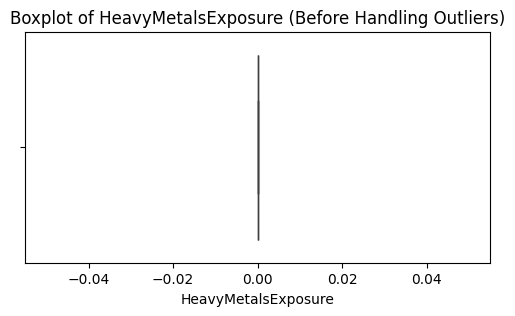

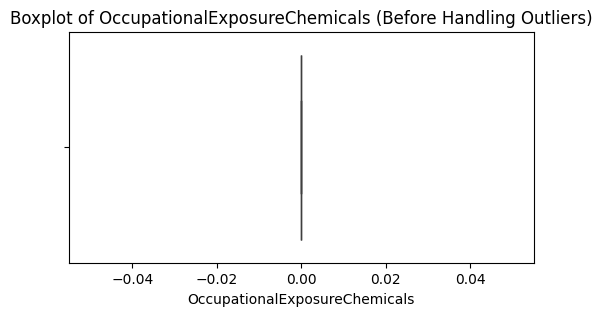

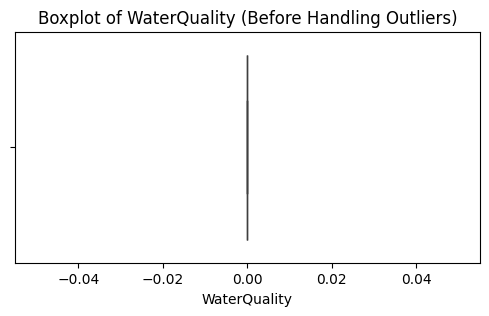

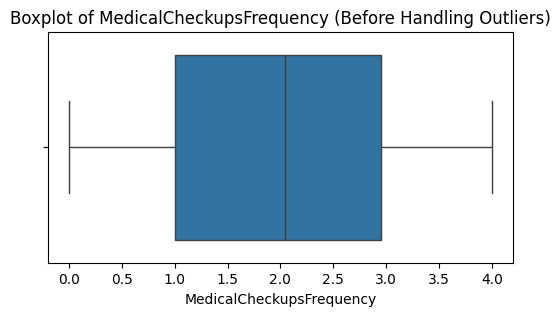

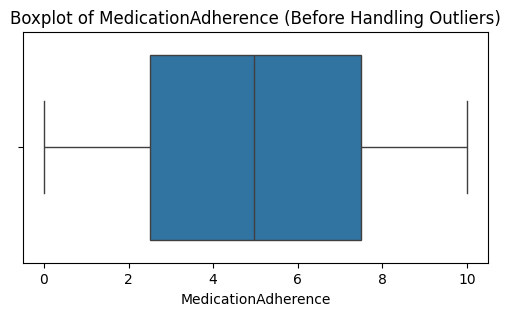

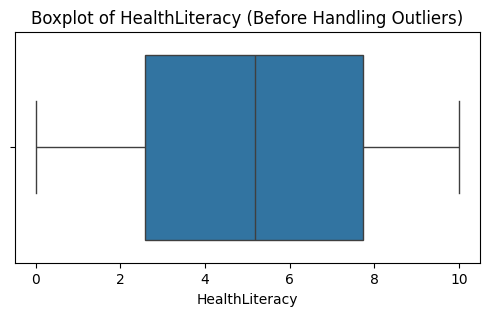

In [16]:
# Boxplots BEFORE Outlier Handling
print("Before Outlier Detection (Boxplots)")

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col} (Before Handling Outliers)")
    plt.show()


# Boxplots AFTER Outlier Handling

After Outlier Detection


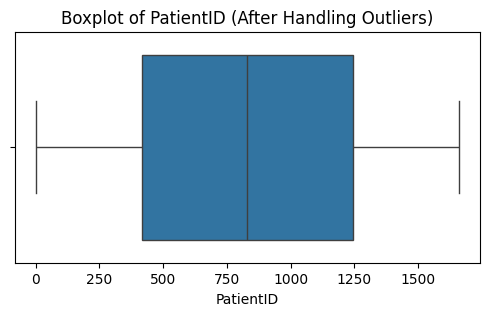

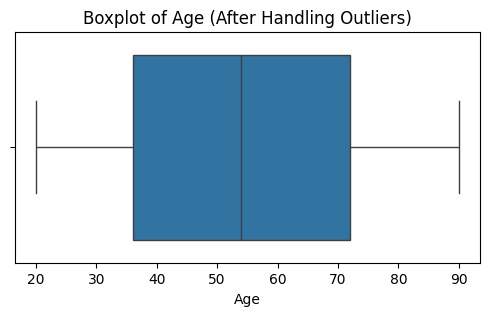

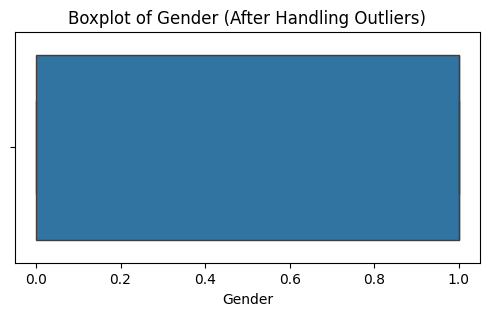

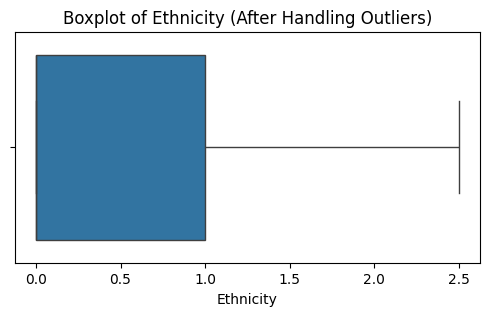

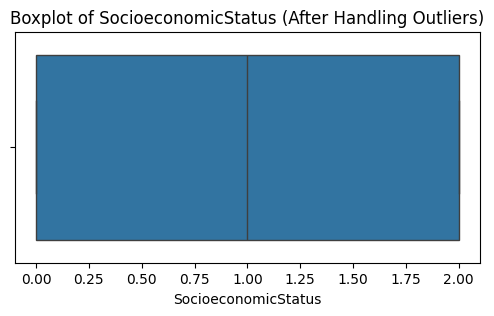

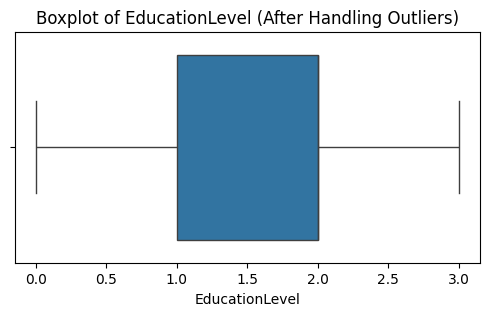

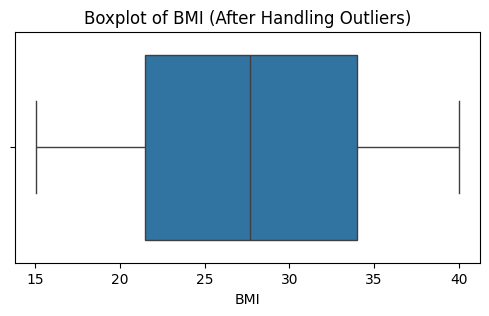

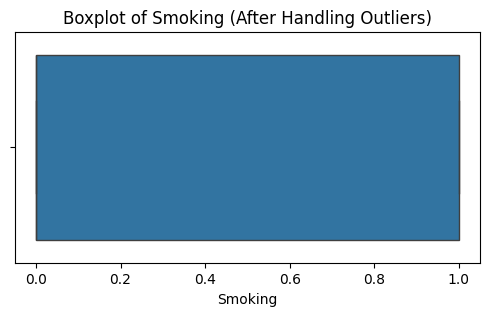

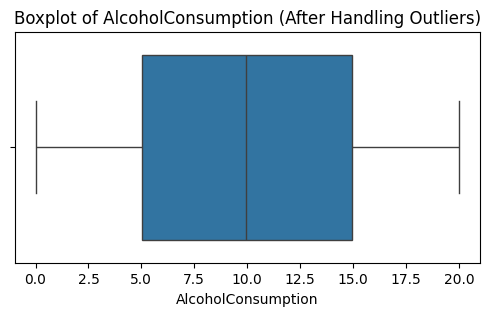

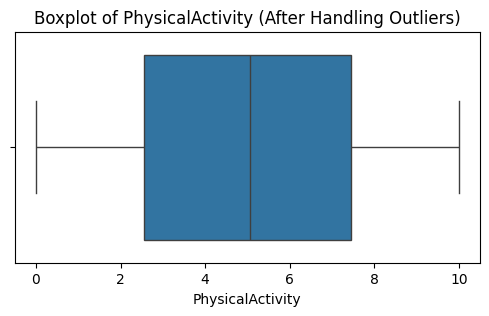

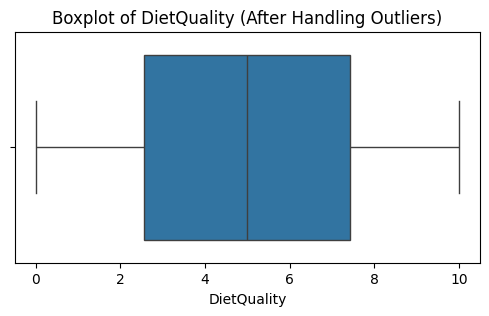

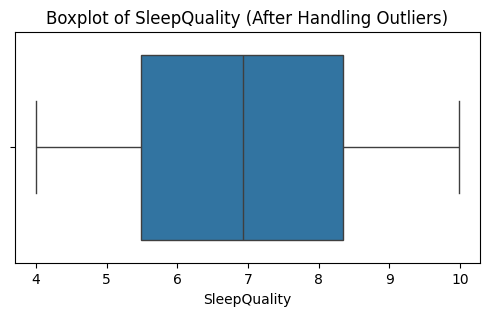

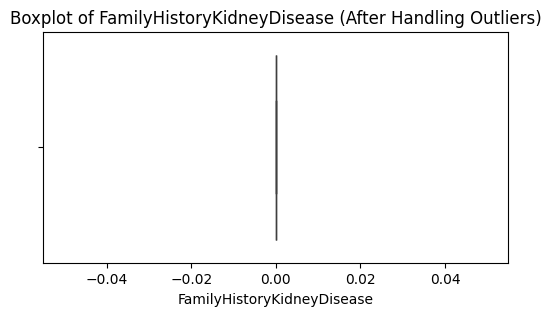

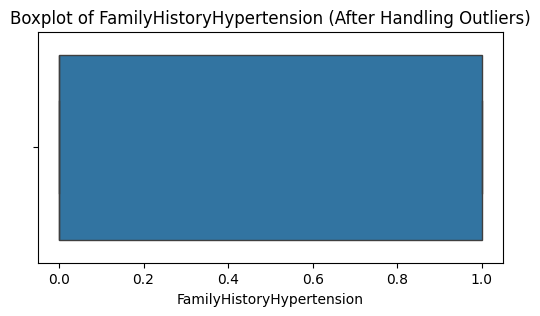

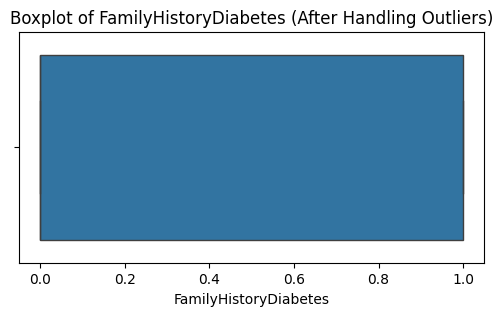

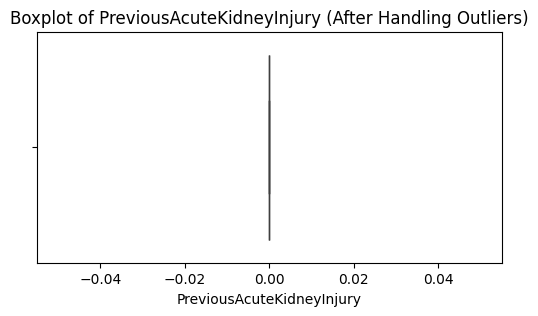

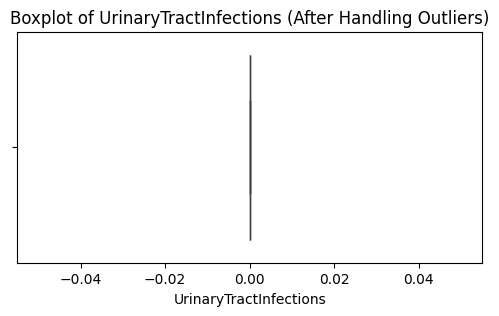

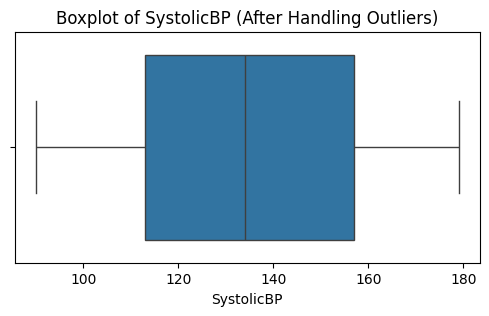

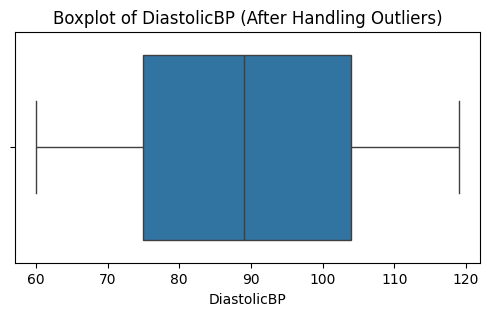

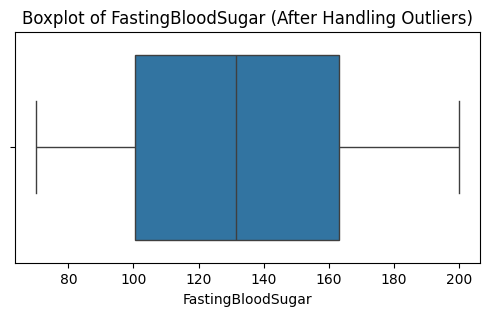

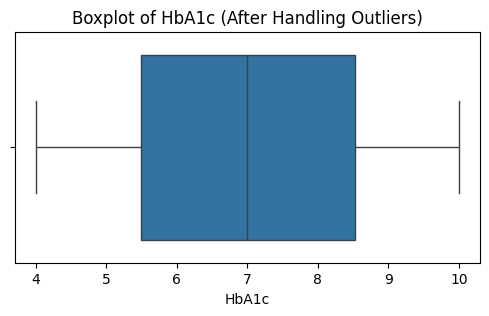

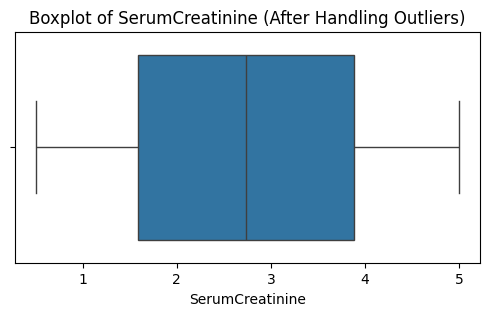

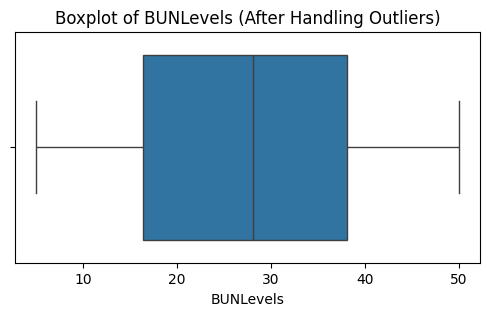

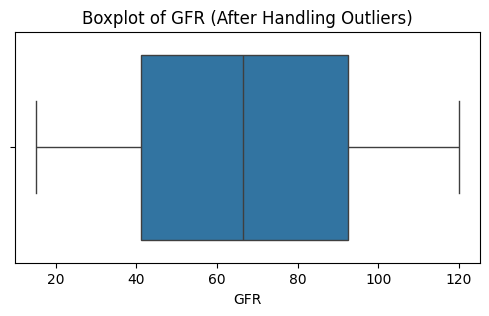

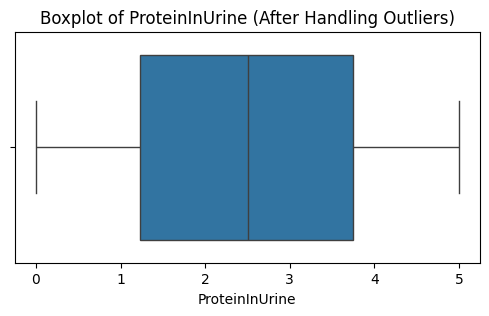

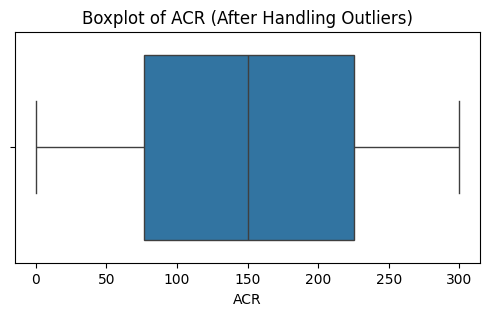

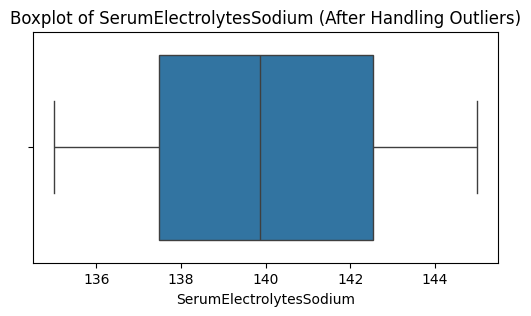

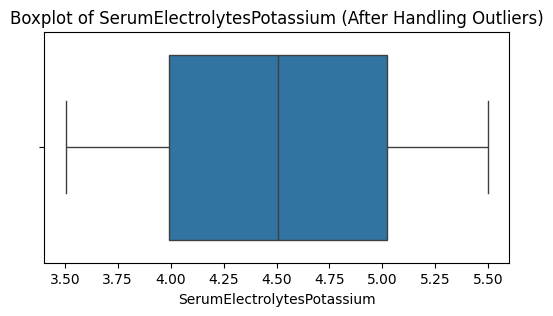

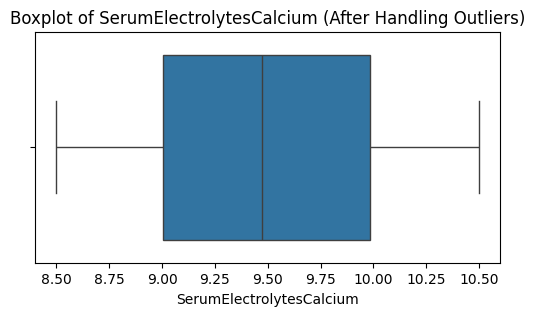

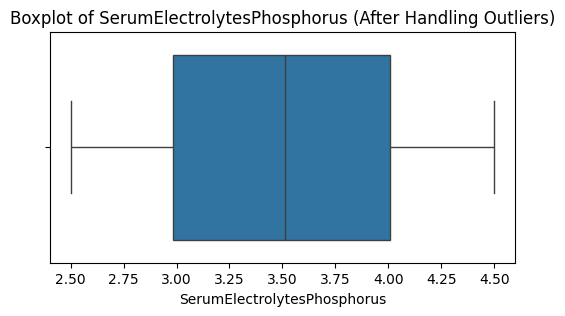

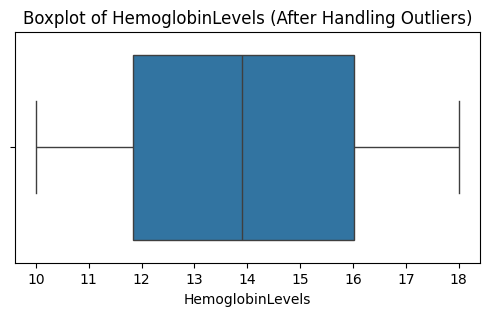

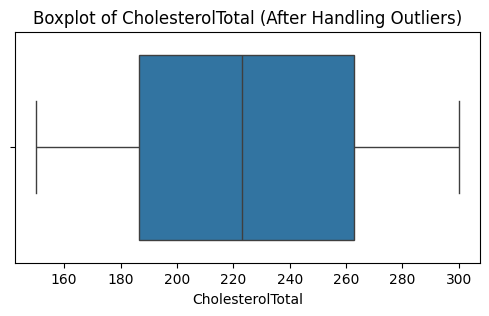

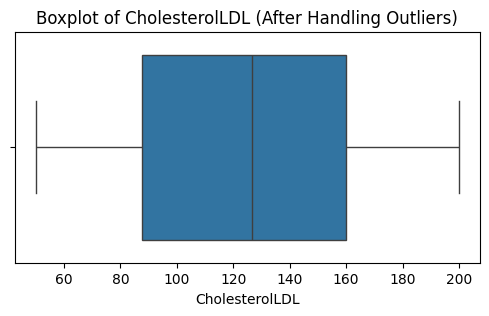

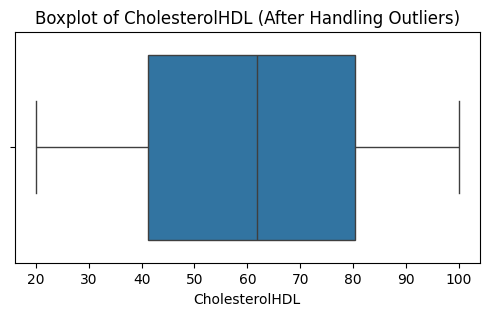

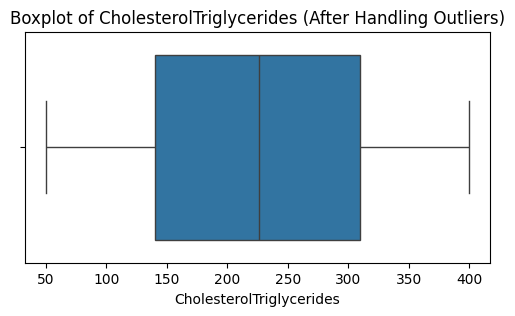

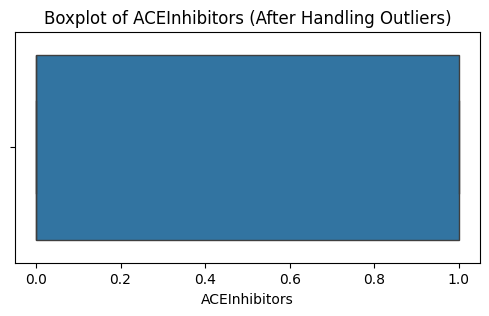

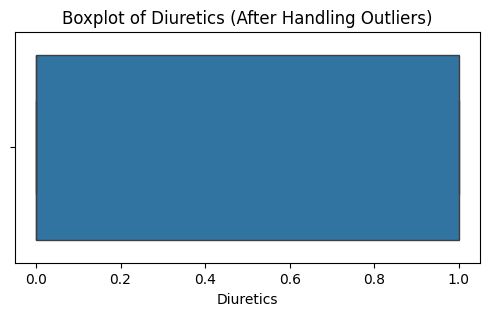

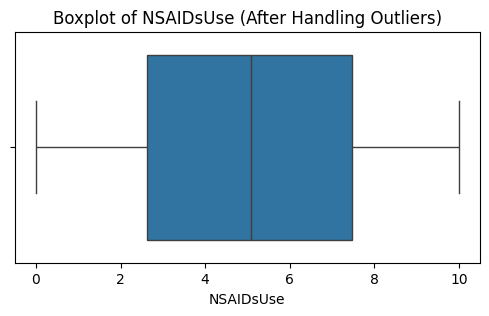

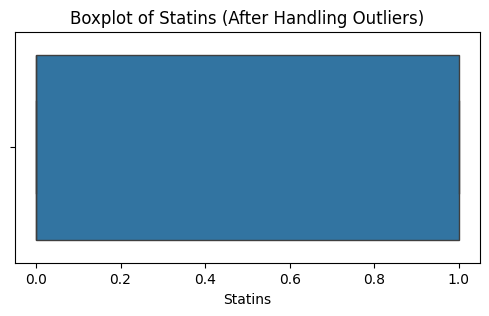

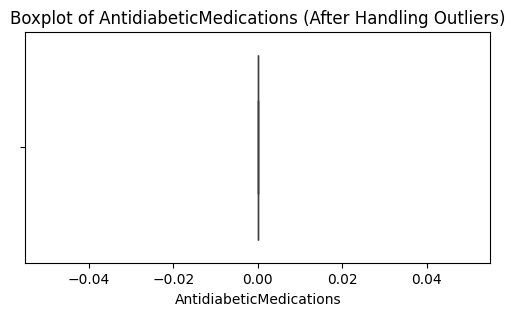

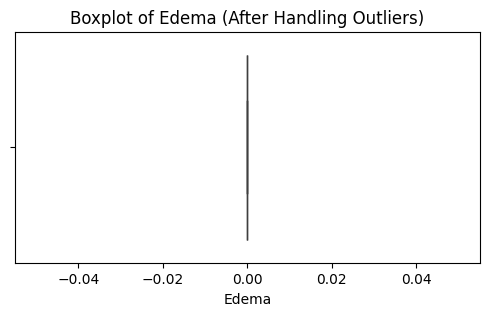

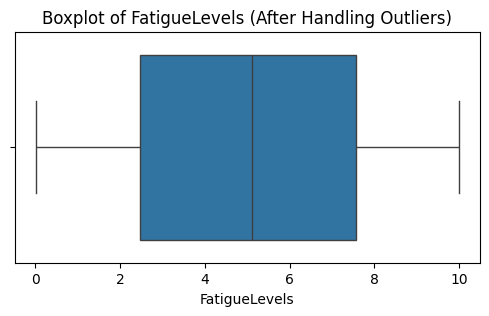

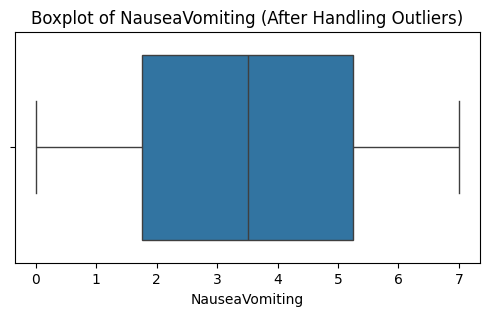

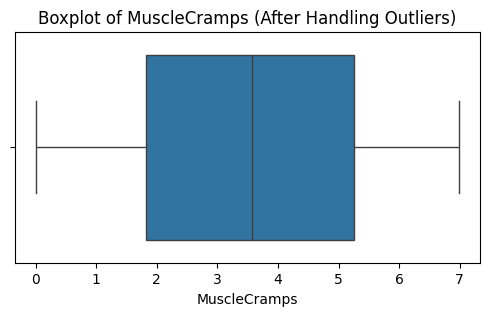

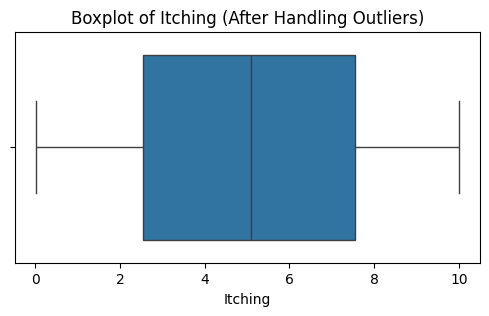

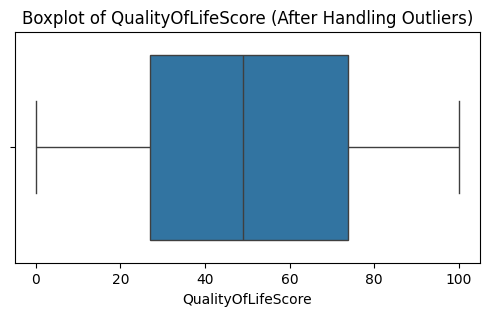

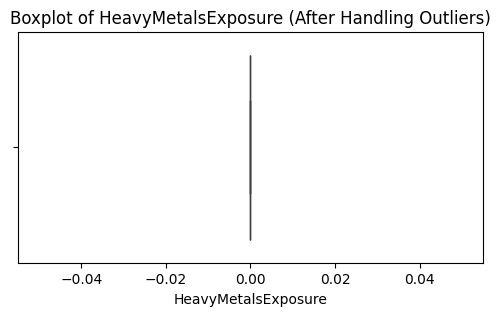

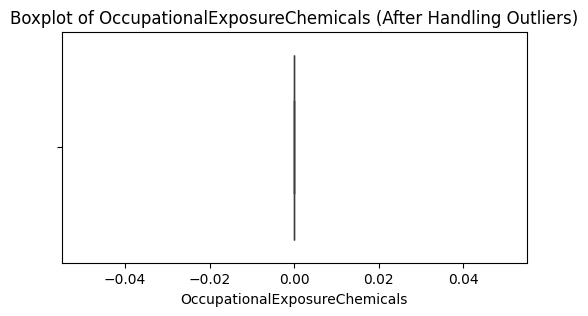

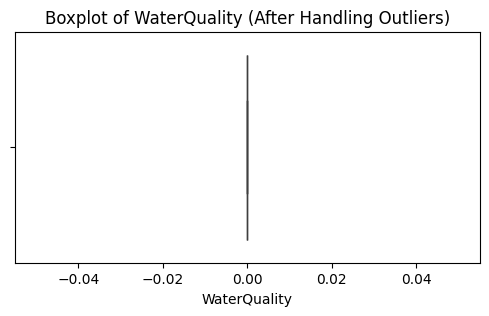

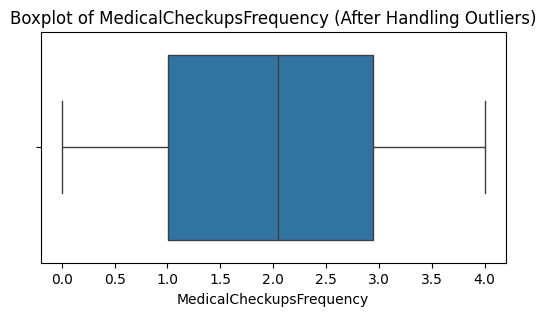

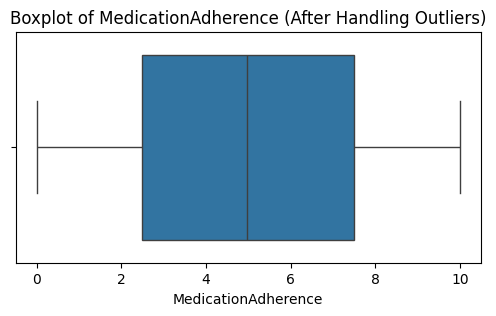

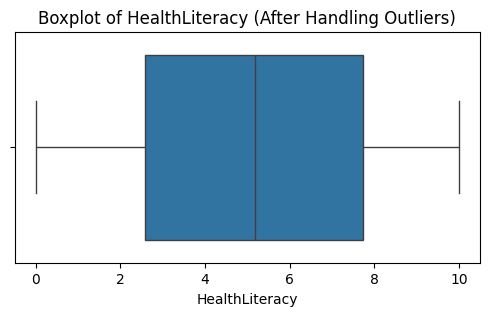

In [17]:
# Boxplots AFTER Outlier Handling
print("After Outlier Detection")

for col in numeric_cols:   # use correct variable name
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])   # df should be the updated dataframe
    plt.title(f"Boxplot of {col} (After Handling Outliers)")
    plt.show()


In [18]:
print(df['Diagnosis'].value_counts())


Diagnosis
1    1524
0     135
Name: count, dtype: int64


# Countplot for Diagnosis Distribution

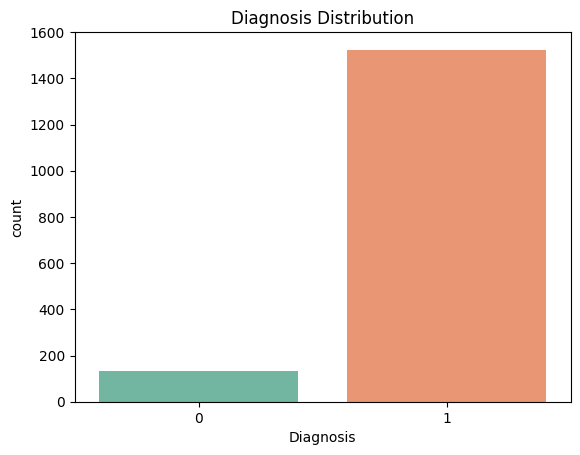

In [19]:
#Countplot for Diagnosis Distribution

sns.countplot(x="Diagnosis", data=df, palette="Set2")
plt.title("Diagnosis Distribution")
plt.show()


Correlation Heatmap
# New Section

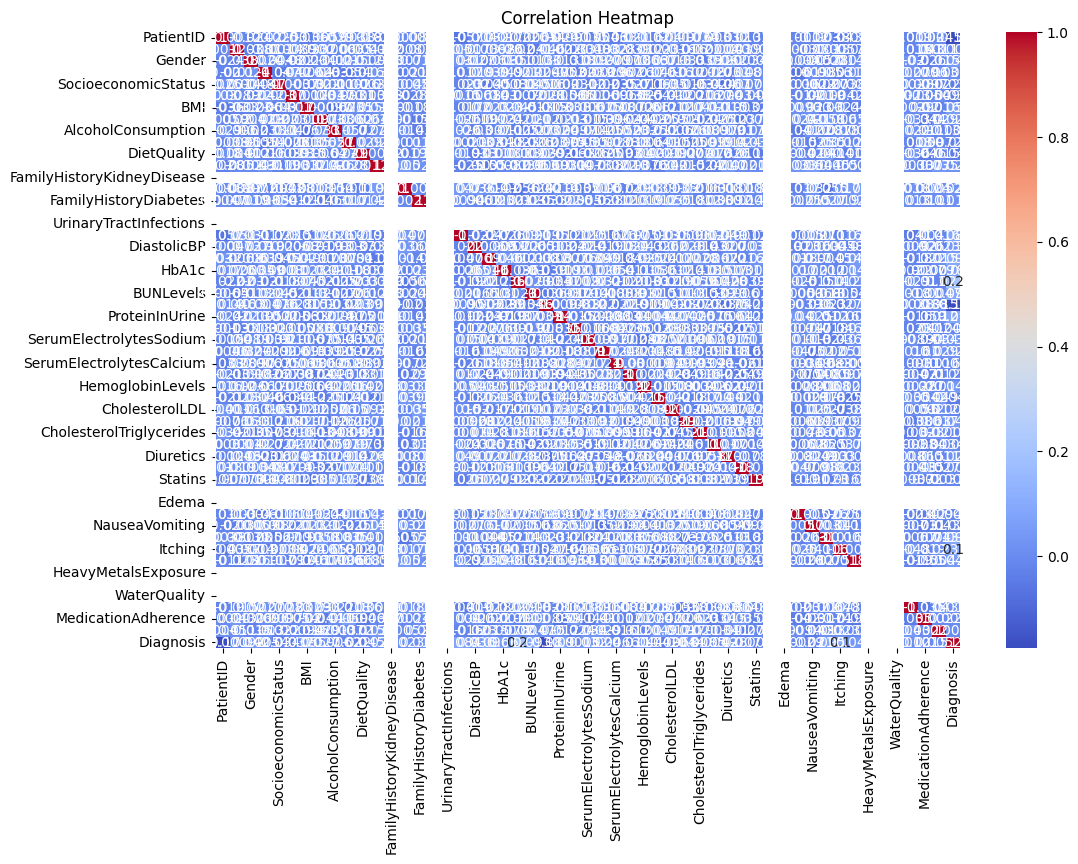

In [20]:
#Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
#Correlation with Target

correlation = df.corr()["Diagnosis"].sort_values(ascending=False)
print(correlation)

Diagnosis                        1.000000
SerumCreatinine                  0.201125
Itching                          0.100652
FastingBloodSugar                0.095694
MuscleCramps                     0.094811
BUNLevels                        0.093097
ProteinInUrine                   0.090014
SystolicBP                       0.083528
HbA1c                            0.059999
BMI                              0.055222
CholesterolHDL                   0.044342
HemoglobinLevels                 0.044001
Gender                           0.042239
QualityOfLifeScore               0.040657
DiastolicBP                      0.036383
SerumElectrolytesSodium          0.032372
Diuretics                        0.028236
Smoking                          0.026875
SerumElectrolytesPotassium       0.023686
FamilyHistoryHypertension        0.022520
SleepQuality                     0.021277
FamilyHistoryDiabetes            0.013852
MedicalCheckupsFrequency         0.012373
NSAIDsUse                        0

# Feature Selection


 Mutual Information Scores (Higher = More Important):

PatientID                        0.047947
SerumCreatinine                  0.023041
GFR                              0.016343
AntidiabeticMedications          0.015813
NSAIDsUse                        0.013335
FastingBloodSugar                0.012216
ProteinInUrine                   0.011825
Gender                           0.010966
PhysicalActivity                 0.010828
WaterQuality                     0.010446
CholesterolHDL                   0.010102
OccupationalExposureChemicals    0.009505
BUNLevels                        0.009362
SerumElectrolytesSodium          0.008848
CholesterolTotal                 0.008313
DietQuality                      0.006665
HbA1c                            0.005698
NauseaVomiting                   0.005294
Age                              0.005262
Ethnicity                        0.005130
CholesterolTriglycerides         0.005011
SerumElectrolytesCalcium         0.004900
Itching             

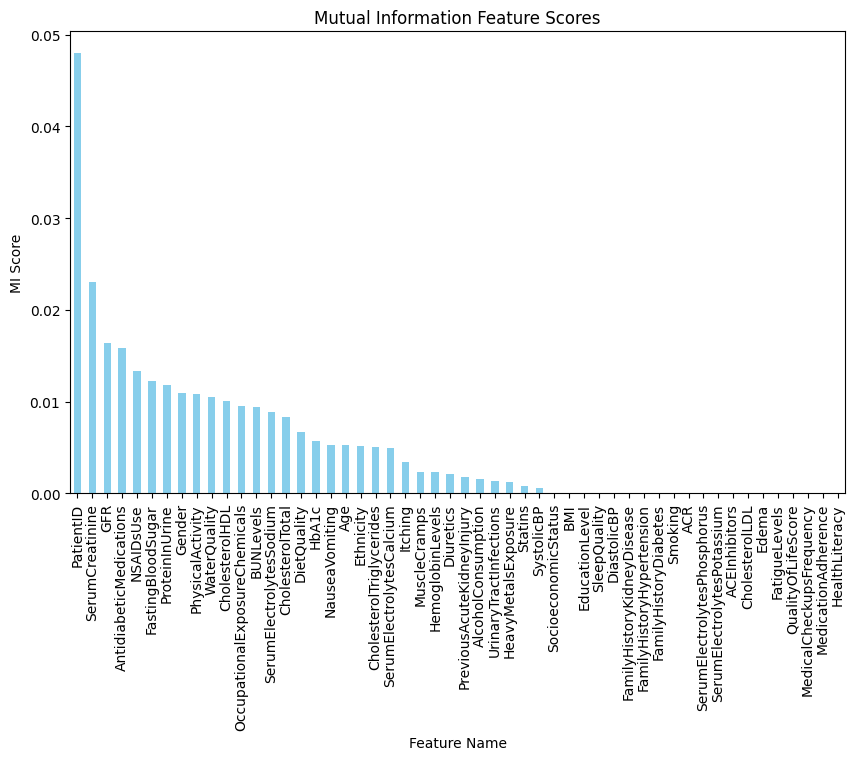

Top Features Selected: ['PatientID', 'PhysicalActivity', 'SystolicBP', 'FastingBloodSugar', 'SerumCreatinine', 'BUNLevels', 'GFR', 'ProteinInUrine', 'CholesterolHDL', 'NSAIDsUse']


In [22]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest
import pandas as pd

# X = features, y = target
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

# 1. Apply Mutual Information
selector = SelectKBest(score_func=mutual_info_classif, k="all")
selector.fit(X, y)

# 2. Get MI scores
mi_scores = pd.Series(selector.scores_, index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)

print("\n Mutual Information Scores (Higher = More Important):\n")
print(mi_scores)

# 3. Plot MI Scores
plt.figure(figsize=(10,6))
mi_scores.plot(kind='bar', color="skyblue")
plt.title("Mutual Information Feature Scores")
plt.xlabel("Feature Name")
plt.ylabel("MI Score")
plt.show()

top_k = 10
selector = SelectKBest(mutual_info_classif, k=top_k)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Top Features Selected:", list(selected_features))


# Selected features

In [23]:
top_features = [
    'PhysicalActivity',
    'UrinaryTractInfections',
    'FastingBloodSugar',
    'SerumCreatinine',
    'GFR',
    'ProteinInUrine',
    'CholesterolHDL',
    'NSAIDsUse',
    'Edema'
]


# Train Test Spliting

In [24]:
X = df[top_features]
y = df["Diagnosis"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Scaling of features

In [25]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


# Balancing The dataset

In [26]:
# SMOTE(Synthetic Minority Oversampling Technique) Oversampling

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After SMOTE:", y_resampled.value_counts())


Before: Diagnosis
1    1216
0     111
Name: count, dtype: int64
After SMOTE: Diagnosis
1    1216
0    1216
Name: count, dtype: int64


# Train Models Manually

In [27]:
X_train_np = np.asarray(X_train, dtype=float)
X_test_np  = np.asarray(X_test, dtype=float)
y_train_np = np.asarray(y_train, dtype=int)
y_test_np  = np.asarray(y_test, dtype=int)


In [28]:
import numpy as np

# MANUAL LOGISTIC REGRESSION

class ManualLogisticRegression:
    def __init__(self, lr=0.01, epochs=2000):
        self.lr = lr
        self.epochs = epochs

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.m, self.n = X.shape
        self.W = np.zeros(self.n)
        self.b = 0

        for _ in range(self.epochs):
            y_pred = self.sigmoid(np.dot(X, self.W) + self.b)

            dw = (1/self.m) * np.dot(X.T, (y_pred - y))
            db = (1/self.m) * np.sum(y_pred - y)

            self.W -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        y_pred = self.sigmoid(np.dot(X, self.W) + self.b)
        return (y_pred >= 0.5).astype(int)


def logistic_accuracy(X_train, X_test, y_train, y_test):
    model = ManualLogisticRegression(lr=0.01, epochs=2000)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = np.mean(preds == y_test)
    print("Manual Logistic Regression Accuracy:", acc)

logistic_accuracy(X_train, X_test, y_train, y_test)


Manual Logistic Regression Accuracy: 0.927710843373494


In [29]:
class ManualDecisionTree:
    def __init__(self, depth=5):
        self.depth = depth

    def gini(self, y):
        g = 1
        for c in np.unique(y):
            p = np.sum(y == c) / len(y)
            g -= p**2
        return g

    def best_split(self, X, y):
        best_f, best_t, best_gain = None, None, -1
        parent_gini = self.gini(y)

        for feature in range(X.shape[1]):
            for t in np.unique(X[:, feature]):

                left = y[X[:, feature] <= t]
                right = y[X[:, feature] > t]

                if len(left) == 0 or len(right) == 0:
                    continue

                g = (len(left)/len(y))*self.gini(left) + (len(right)/len(y))*self.gini(right)
                gain = parent_gini - g

                if gain > best_gain:
                    best_gain = gain
                    best_f = feature
                    best_t = t

        return best_f, best_t

    def build(self, X, y, depth):
        if depth == 0 or len(np.unique(y)) == 1:
            return np.argmax(np.bincount(y))

        f, t = self.best_split(X, y)
        if f is None:
            return np.argmax(np.bincount(y))

        left_idx = X[:, f] <= t
        right_idx = X[:, f] > t

        return {
            'f': f,
            't': t,
            'left': self.build(X[left_idx], y[left_idx], depth-1),
            'right': self.build(X[right_idx], y[right_idx], depth-1)
        }

    def fit(self, X, y):
        self.tree = self.build(X, y, self.depth)

    def _predict(self, node, x):
        if not isinstance(node, dict):
            return node
        if x[node['f']] <= node['t']:
            return self._predict(node['left'], x)
        return self._predict(node['right'], x)

    def predict(self, X):
        return np.array([self._predict(self.tree, row) for row in X])


def dt_acc():
    model = ManualDecisionTree(depth=5)
    model.fit(X_train_np, y_train_np)
    preds = model.predict(X_test_np)
    acc = np.mean(preds == y_test_np)
    print("Manual Decision Tree Accuracy:", acc)

dt_acc()


Manual Decision Tree Accuracy: 0.9246987951807228


In [30]:
class ManualRandomForest:
    def __init__(self, n_trees=5, max_samples=0.7):
        self.n_trees = n_trees
        self.max_samples = max_samples
        self.trees = []

    def bootstrap(self, X, y):
        idx = np.random.choice(len(X), int(len(X)*self.max_samples), replace=True)
        return X[idx], y[idx]

    def fit(self, X, y):
        for _ in range(self.n_trees):
            X_s, y_s = self.bootstrap(X, y)
            tree = ManualDecisionTree(depth=5)
            tree.fit(X_s, y_s)
            self.trees.append(tree)

    def predict(self, X):
        all_preds = np.array([t.predict(X) for t in self.trees])
        final = []
        for i in range(len(X)):
            final.append(np.bincount(all_preds[:, i]).argmax())
        return np.array(final)


def rf_acc():
    model = ManualRandomForest()
    model.fit(X_train_np, y_train_np)
    preds = model.predict(X_test_np)
    acc = np.mean(preds == y_test_np)
    print("Manual Random Forest Accuracy:", acc)

rf_acc()


Manual Random Forest Accuracy: 0.9156626506024096


In [31]:
class ManualKNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X = X
        self.y = y

    def predict_one(self, x):
        dist = np.sqrt(np.sum((self.X - x)**2, axis=1))
        idx = dist.argsort()[:self.k]
        return np.bincount(self.y[idx]).argmax()

    def predict(self, X_test):
        return np.array([self.predict_one(x) for x in X_test])


def knn_acc():
    model = ManualKNN(k=5)
    model.fit(X_train_np, y_train_np)
    preds = model.predict(X_test_np)
    acc = np.mean(preds == y_test_np)
    print("Manual KNN Accuracy:", acc)

knn_acc()


Manual KNN Accuracy: 0.9337349397590361


In [32]:


#   MANUAL GAUSSIAN NAIVE BAYES CLASSIFIER


class ManualNaiveBayes:
    def fit(self, X, y):
        self.X = X
        self.y = y
        self.classes = np.unique(y)

        self.mean = {}
        self.var = {}
        self.prior = {}

        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = X_c.mean(axis=0)
            self.var[c] = X_c.var(axis=0) + 1e-9
            self.prior[c] = len(X_c) / len(X)

    def gaussian_prob(self, class_idx, x):
        mean = self.mean[class_idx]
        var  = self.var[class_idx]

        numerator = np.exp(-(x - mean)**2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)

        return numerator / denominator

    def predict_one(self, x):
        posteriors = []

        for c in self.classes:
            prior = np.log(self.prior[c])
            conditional = np.sum(np.log(self.gaussian_prob(c, x)))
            posterior = prior + conditional
            posteriors.append(posterior)

        return self.classes[np.argmax(posteriors)]

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])


#  ACCURACY FUNCTION

def nb_accuracy(X_train, X_test, y_train, y_test):
    model = ManualNaiveBayes()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = np.mean(preds == y_test)
    print("Manual Naive Bayes Accuracy:", acc)

    return acc


#  RUN MANUAL NAIVE BAYES

nb_accuracy(X_train, X_test, y_train, y_test)


Manual Naive Bayes Accuracy: 0.927710843373494


np.float64(0.927710843373494)


 ACCURACY OF ALL MANUAL MODELS 


Manual Logistic Regression Accuracy: 0.9277
Confusion Matrix:
 [[  0  24]
 [  0 308]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.93      1.00      0.96       308

    accuracy                           0.93       332
   macro avg       0.46      0.50      0.48       332
weighted avg       0.86      0.93      0.89       332


Manual KNN Accuracy: 0.9337
Confusion Matrix:
 [[  3  21]
 [  1 307]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.12      0.21        24
           1       0.94      1.00      0.97       308

    accuracy                           0.93       332
   macro avg       0.84      0.56      0.59       332
weighted avg       0.92      0.93      0.91       332


Manual Naive Bayes Accuracy: 0.9277
Confusion Matrix:
 [[  0  24]
 [  0 308]]
Classification Report:
    

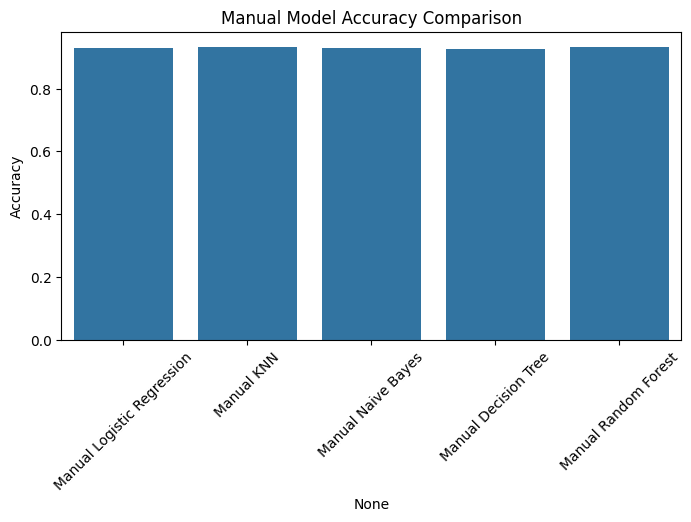

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Convert Train/Test into numpy

X_train_np = np.asarray(X_train, dtype=float)
X_test_np  = np.asarray(X_test, dtype=float)
y_train_np = np.asarray(y_train, dtype=int)
y_test_np  = np.asarray(y_test, dtype=int)

# Initialize all manual models

manual_models = {
    "Manual Logistic Regression": ManualLogisticRegression(lr=0.01, epochs=2000),
    "Manual KNN": ManualKNN(k=5),
    "Manual Naive Bayes": ManualNaiveBayes(),
    "Manual Decision Tree": ManualDecisionTree(depth=3),
    "Manual Random Forest": ManualRandomForest(n_trees=5, max_samples=0.7)
}


# FIT ALL MODELS

for name, model in manual_models.items():
    model.fit(X_train_np, y_train_np)


# PRINT ACCURACY, CONFUSION MATRIX, CLASSIFICATION REPORT

print("\n ACCURACY OF ALL MANUAL MODELS \n")

manual_accuracy_results = {}

for name, model in manual_models.items():

    y_pred = model.predict(X_test_np)

    acc = accuracy_score(y_test_np, y_pred)
    manual_accuracy_results[name] = acc

    print(f"\n{name} Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test_np, y_pred))
    print("Classification Report:\n", classification_report(y_test_np, y_pred))


# ACCURACY TABLE

manual_accuracy_df = pd.DataFrame.from_dict(
    manual_accuracy_results,
    orient='index',
    columns=["Accuracy"]
)

print("\n FINAL MANUAL MODEL ACCURACY COMPARISON\n")
print(manual_accuracy_df)


# BARPLOT FOR MANUAL MODEL ACCURACIES

plt.figure(figsize=(8,4))
sns.barplot(x=manual_accuracy_df.index, y=manual_accuracy_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Manual Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


# Train Models

In [34]:

#  TRAIN MODELS


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Initialize all models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

# Train models
for name, model in models.items():
    model.fit(X_train, y_train)


# EVALUATION

In [35]:

# 3. EVALUATION FUNCTION


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(model):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    cr = classification_report(y_test, preds)
    return acc, cm, cr


# RESULTS

In [36]:

# 4. GET RESULTS FOR EACH MODEL


results = {}

for name, model in models.items():
    acc, cm, cr = evaluate_model(model)
    results[name] = {
        "Accuracy": acc,
        "Confusion Matrix": cm,
        "Classification Report": cr,
        "Predictions": model.predict(X_test)
    }
    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", cr)



===== Logistic Regression =====
Accuracy: 0.9307228915662651

Confusion Matrix:
 [[  1  23]
 [  0 308]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.04      0.08        24
           1       0.93      1.00      0.96       308

    accuracy                           0.93       332
   macro avg       0.97      0.52      0.52       332
weighted avg       0.94      0.93      0.90       332


===== Decision Tree =====
Accuracy: 0.891566265060241

Confusion Matrix:
 [[  8  16]
 [ 20 288]]

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.33      0.31        24
           1       0.95      0.94      0.94       308

    accuracy                           0.89       332
   macro avg       0.62      0.63      0.62       332
weighted avg       0.90      0.89      0.90       332


===== KNN =====
Accuracy: 0.9337349397590361

Confusion Matrix:
 [[  3  21]
 [  1 307]]

Cla

## CONFUSION MATRIX

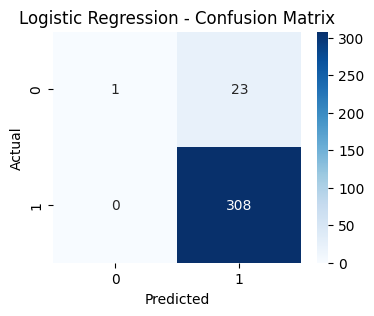

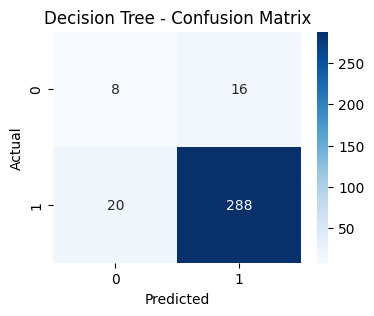

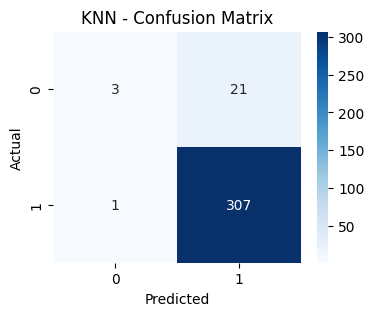

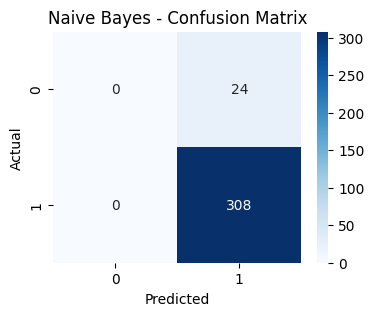

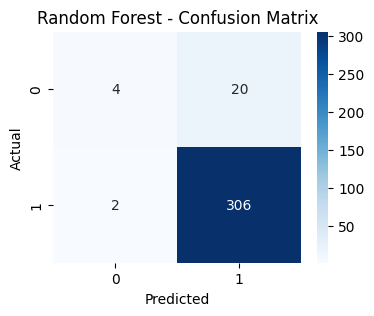

In [37]:

# 5. CONFUSION MATRIX HEATMAPS


import matplotlib.pyplot as plt
import seaborn as sns

for name in results:
    plt.figure(figsize=(4,3))
    sns.heatmap(results[name]["Confusion Matrix"], annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# Accuracy Comparision

In [38]:

# 6. FINAL ACCURACY COMPARISON


import pandas as pd

accuracy_table = pd.DataFrame(
    {name: results[name]["Accuracy"] for name in results},
    index=["Accuracy"]
).T

print("\n FINAL ACCURACY COMPARISON TABLE ")
print(accuracy_table)



 FINAL ACCURACY COMPARISON TABLE 
                     Accuracy
Logistic Regression  0.930723
Decision Tree        0.891566
KNN                  0.933735
Naive Bayes          0.927711
Random Forest        0.933735


# ACCURACY BAR PLOT

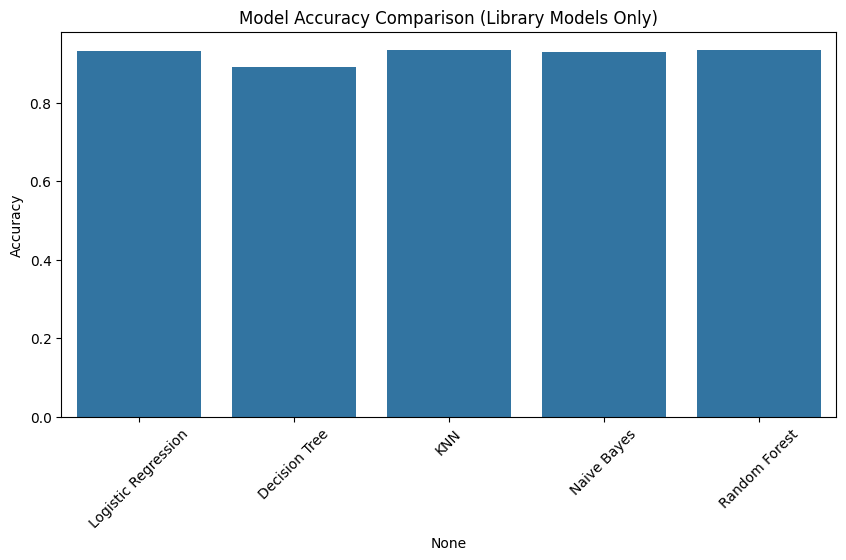

In [39]:

# 7. ACCURACY BAR PLOT


plt.figure(figsize=(10,5))
sns.barplot(x=accuracy_table.index, y=accuracy_table['Accuracy'])
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison (Library Models Only)")
plt.ylabel("Accuracy")
plt.show()


# CROSS-VALIDATION

In [40]:

# 1. CROSS-VALIDATION ACCURACY FOR ALL MODELS


from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = cv_scores.mean()
    print(f"{name} | CV Accuracy = {cv_scores.mean():.4f}")


Logistic Regression | CV Accuracy = 0.9186
Decision Tree | CV Accuracy = 0.8779
KNN | CV Accuracy = 0.9096
Naive Bayes | CV Accuracy = 0.9179
Random Forest | CV Accuracy = 0.9141


# ROC–AUC CURVES

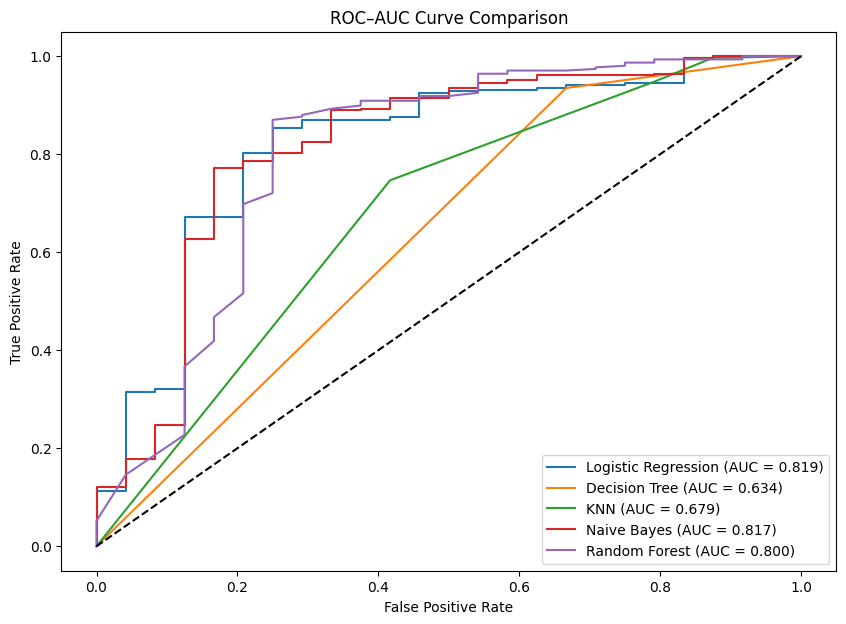

In [41]:

# 2. PLOT ROC–AUC CURVES FOR ALL MODELS


from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,7))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        # For SVM without probability=True (not in your case)
        try:
            y_prob = model.decision_function(X_test)
        except:
            continue

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve Comparison")
plt.legend()
plt.show()


# Hyperparameter Tuning

#  Logistic Regression Grid Search

In [42]:
from sklearn.model_selection import GridSearchCV

param_lr = {
    "C": [0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=2000), param_lr, cv=5, scoring="accuracy")
grid_lr.fit(X_train, y_train)

print("Best Logistic Regression:", grid_lr.best_params_)


Best Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


# Decision Tree Grid Search

In [43]:
param_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(), param_dt, cv=5, scoring="accuracy")
grid_dt.fit(X_train, y_train)

print("Best Decision Tree:", grid_dt.best_params_)


Best Decision Tree: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}


# KNN Grid Search

In [44]:
param_knn = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["minkowski", "manhattan"]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5, scoring="accuracy")
grid_knn.fit(X_train, y_train)

print("Best KNN:", grid_knn.best_params_)


Best KNN: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}


# Random Forest Grid Search

In [45]:
param_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "bootstrap": [True, False]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_rf, cv=5, scoring="accuracy")
grid_rf.fit(X_train, y_train)

print("Best Random Forest:", grid_rf.best_params_)


Best Random Forest: {'bootstrap': False, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}


In [46]:
best_log_reg = grid_lr.best_estimator_
best_dt = grid_dt.best_estimator_
best_rf = grid_rf.best_estimator_
best_knn = grid_knn.best_estimator_
best_nb = GaussianNB() # Naive Bayes doesn't have a grid search defined yet, so re-initialize


 ACCURACY AFTER HYPERPARAMETER TUNING 


 Logistic Regression Accuracy: 0.9307
Confusion Matrix:
 [[  1  23]
 [  0 308]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.04      0.08        24
           1       0.93      1.00      0.96       308

    accuracy                           0.93       332
   macro avg       0.97      0.52      0.52       332
weighted avg       0.94      0.93      0.90       332


 Decision Tree Accuracy: 0.9247
Confusion Matrix:
 [[  6  18]
 [  7 301]]
Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.25      0.32        24
           1       0.94      0.98      0.96       308

    accuracy                           0.92       332
   macro avg       0.70      0.61      0.64       332
weighted avg       0.91      0.92      0.91       332


 Random Forest Accuracy: 0.9337
Confusion Matrix:
 [[  2  22]
 [  0 308]]
Classification Report:
   

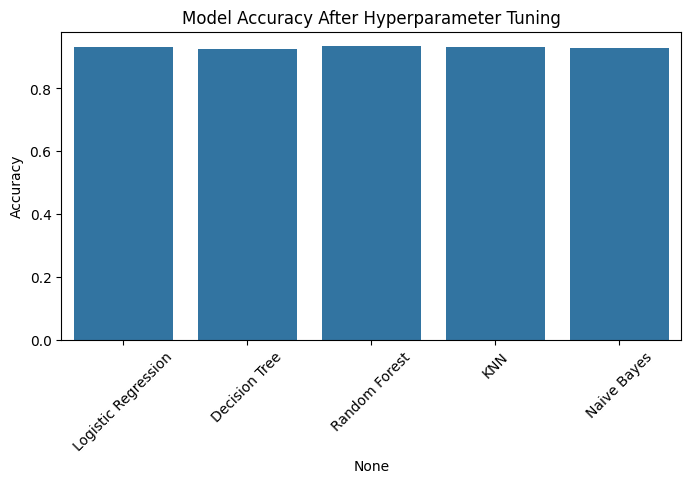

In [47]:

# ACCURACY AFTER HYPERPARAMETER TUNING (ALL MODELS)


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Store tuned models and their names
tuned_models = {
    "Logistic Regression": best_log_reg,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "KNN": best_knn,
    "Naive Bayes": best_nb
}

# Fit the Naive Bayes model after re-initialization
best_nb.fit(X_train, y_train)

print("\n ACCURACY AFTER HYPERPARAMETER TUNING \n")

accuracy_results = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc

    print(f"\n {name} Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

# Create comparison table
accuracy_df = pd.DataFrame.from_dict(accuracy_results, orient='index', columns=["Accuracy"])

print("\n FINAL ACCURACY COMPARISON\n")
print(accuracy_df)

# Accuracy bar plot
plt.figure(figsize=(8,4))
sns.barplot(x=accuracy_df.index, y=accuracy_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Model Accuracy After Hyperparameter Tuning")
plt.ylabel("Accuracy")
plt.show()


Final Manual vs Library Model Accuracy Comparison:

              Model  Manual Accuracy  Library Accuracy
Logistic Regression         0.927711          0.930723
                KNN         0.933735          0.927711
        Naive Bayes         0.927711          0.930723
      Decision Tree         0.924699          0.930723
      Random Forest         0.915663          0.939759


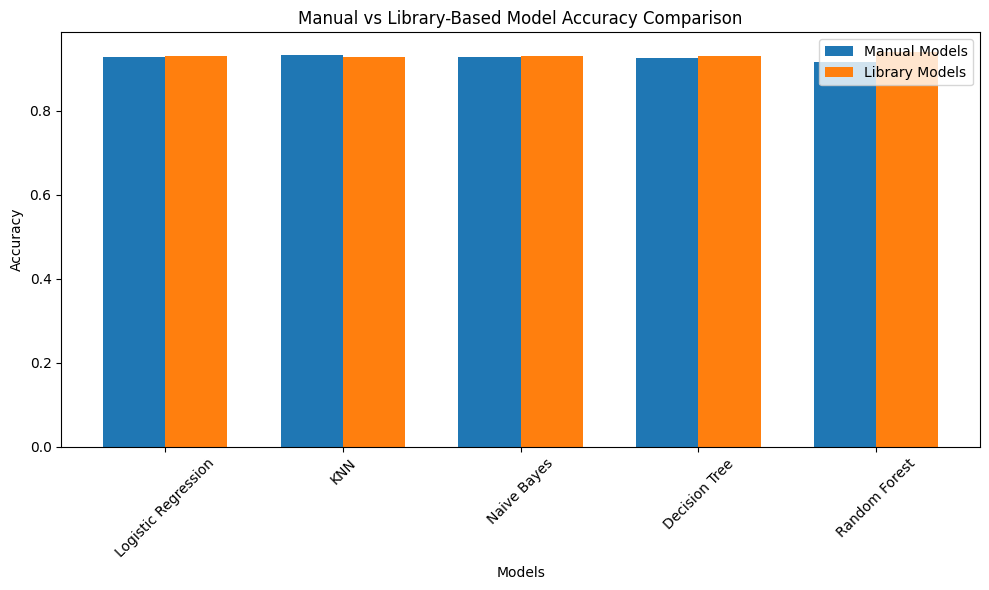

In [48]:


# Manual model accuracies
manual_models = ['Logistic Regression', 'KNN', 'Naive Bayes', 'Decision Tree', 'Random Forest']
manual_accuracies = [0.927711, 0.933735, 0.927711, 0.924699, 0.915663]

# Library-based model accuracies
library_accuracies = [0.930723, 0.927711, 0.930723, 0.930723, 0.939759]

# Create and print comparison dataframe
df = pd.DataFrame({
    'Model': manual_models,
    'Manual Accuracy': manual_accuracies,
    'Library Accuracy': library_accuracies
})

print("Final Manual vs Library Model Accuracy Comparison:\n")
print(df.to_string(index=False))

# Plotting
x = np.arange(len(manual_models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, manual_accuracies, width, label='Manual Models')
plt.bar(x + width/2, library_accuracies, width, label='Library Models')

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Manual vs Library-Based Model Accuracy Comparison')
plt.xticks(x, manual_models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [49]:

# 1. LOAD SAVED ARTIFACTS

import joblib
import pandas as pd
import numpy as np
import os

# Define the directory for artifacts
artifacts_dir = "nephropredict_artifacts"

# Create the directory if it doesn't exist
os.makedirs(artifacts_dir, exist_ok=True)

# Save the best model (Random Forest had the highest accuracy)
joblib.dump(best_rf, os.path.join(artifacts_dir, "nephropredict_best_model.pkl"))

# Save the StandardScaler (sc was used for scaling)
joblib.dump(sc, os.path.join(artifacts_dir, "nephropredict_scaler.pkl"))

# Save the list of selected features (top_features was used for X)
joblib.dump(top_features, os.path.join(artifacts_dir, "nephropredict_feature_list.pkl"))

# Note: There were no label encoders created in this notebook, so saving an empty dict or similar.
# If categorical features were one-hot encoded, you might save the OneHotEncoder here.
joblib.dump({}, os.path.join(artifacts_dir, "nephropredict_label_encoders.pkl"))

print("Artifacts saved successfully.")

# Now, load the saved artifacts
loaded_model = joblib.load(os.path.join(artifacts_dir, "nephropredict_best_model.pkl"))
loaded_scaler = joblib.load(os.path.join(artifacts_dir, "nephropredict_scaler.pkl"))
loaded_label_encoders = joblib.load(os.path.join(artifacts_dir, "nephropredict_label_encoders.pkl"))
feature_list = joblib.load(os.path.join(artifacts_dir, "nephropredict_feature_list.pkl"))

print("Artifacts loaded successfully after saving.")


Artifacts saved successfully.
Artifacts loaded successfully after saving.


In [50]:

# 2. NEW PATIENT INPUT (TO PREDICT CKD)


new_data = {
    'Age': 45, 'Gender': 0, 'Ethnicity': 0, 'SocioeconomicStatus': 0, 'EducationLevel': 2,
    'BMI': 25.0, 'Smoking': 0, 'AlcoholConsumption': 5.0, 'PhysicalActivity': 3.0,
    'DietQuality': 7.0, 'SleepQuality': 7.0, 'FamilyHistoryKidneyDisease': 0,
    'FamilyHistoryHypertension': 0, 'FamilyHistoryDiabetes': 0, 'PreviousAcuteKidneyInjury': 0,
    'UrinaryTractInfections': 0, 'SystolicBP': 120, 'DiastolicBP': 80, 'FastingBloodSugar': 110,
    'HbA1c': 6.0, 'SerumCreatinine': 1.2, 'BUNLevels': 20, 'GFR': 90, 'ProteinInUrine': 0,
    'ACR': 10, 'SerumElectrolytesSodium': 140, 'SerumElectrolytesPotassium': 4.0,
    'SerumElectrolytesCalcium': 9.0, 'SerumElectrolytesPhosphorus': 3.0,
    'HemoglobinLevels': 14.0, 'CholesterolTotal': 200,
    'CholesterolLDL': 120, 'CholesterolHDL': 50, 'CholesterolTriglycerides': 150,
    'ACEInhibitors': 0, 'Diuretics': 0, 'NSAIDsUse': 0, 'Statins': 0, 'AntidiabeticMedications': 0,
    'Edema': 0, 'FatigueLevels': 5.0, 'NauseaVomiting': 2.0, 'MuscleCramps': 2.0,
    'Itching': 2.0, 'QualityOfLifeScore': 80, 'HeavyMetalsExposure': 0,
    'OccupationalExposureChemicals': 0, 'WaterQuality': 0, 'MedicalCheckupsFrequency': 1.0,
    'MedicationAdherence': 5.0, 'HealthLiteracy': 8.0
}

# Convert to DataFrame in correct order
new_input = pd.DataFrame([new_data])[feature_list]


In [51]:

# 3. PREPROCESS & PREDICT CKD


# Detect types
cat_cols = new_input.select_dtypes(include=['object']).columns
num_cols = new_input.select_dtypes(include=[np.number]).columns

# Encode categorical columns
for col in cat_cols:
    if col in loaded_label_encoders:
        new_input[col] = loaded_label_encoders[col].transform(new_input[col].astype(str))

# Scale numerical columns
new_input[num_cols] = loaded_scaler.transform(new_input[num_cols])

# Prediction
prediction = loaded_model.predict(new_input)[0]
probability = loaded_model.predict_proba(new_input)[0][1]

print("\n CKD PREDICTION RESULT ")
if prediction == 1:
    print(" Prediction: Chronic Kidney Disease Detected")
    print(f" Confidence: {probability:.2f}")
else:
    print(" Prediction: No CKD Detected")
    print(f" Confidence: {probability:.2f}")
print("")



 CKD PREDICTION RESULT 
 Prediction: No CKD Detected
 Confidence: 0.23

